In [1]:
# Импортируем библиотеки

import numpy as np
import pandas as pd
import seaborn as sns
sns.set_palette('husl')
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split

In [2]:
# Присвоим переменной «url» ссылку на датасет:

url = '/content/global_cars_dataset_synthetic.csv'

# создаем лист с названием столбцов:

cols = ['Car_ID', 'Brand', 'Manufacture_Year', 'Body_Type', 'Fuel_Type', 'Transmission', 'Engine_CC', 'Horsepower', 'Mileage_km_per_l', 'Price_USD', 'Manufacturing_Country']
# используем Pandas read_csv():

dataset = pd.read_csv(url, names = cols)

In [3]:
dataset.head()


,Car_ID,Brand,Manufacture_Year,Body_Type,Fuel_Type,Transmission,Engine_CC,Horsepower,Mileage_km_per_l,Price_USD,Manufacturing_Country
0,Car_ID,Brand,Manufacture_Year,Body_Type,Fuel_Type,Transmission,Engine_CC,Horsepower,Mileage_km_per_l,Price_USD,Manufacturing_Country
1,CAR_0001,Mercedes,2006,SUV,Petrol,Manual,4089,547,17,73407,USA
2,CAR_0002,Nissan,2023,Coupe,Petrol,Automatic,4618,167,25,79370,USA
3,CAR_0003,Nissan,2007,Hatchback,Diesel,Manual,1802,110,16,76549,China
4,CAR_0004,Nissan,2013,Coupe,Petrol,Manual,1835,373,16,48722,USA


In [4]:
vals = dataset["Brand"].unique()
vals

array(['Brand', 'Mercedes', 'Nissan', 'Hyundai', 'Tesla', 'Audi', 'Honda',
       'Ford', 'Toyota', 'BMW', 'Kia'], dtype=object)

категориальные в числовые переводим

In [34]:
# сохраняем только числовые столбцы. Категориальные кодируем в числовые. Целевую переменную (если она есть) - убираем
cols_for_clusters = ['Car_ID', 'Brand', 'Manufacture_Year', 'Body_Type', 'Fuel_Type', 'Transmission', 'Engine_CC', 'Horsepower', 'Mileage_km_per_l', 'Price_USD', 'Manufacturing_Country']

df= dataset[cols_for_clusters].copy() # делаем копию, чтобы не было сюрпризов с исходным набором данных

In [36]:
df.head()

,Car_ID,Brand,Manufacture_Year,Body_Type,Fuel_Type,Transmission,Engine_CC,Horsepower,Mileage_km_per_l,Price_USD,Manufacturing_Country
0,300.0,2.0,21.0,0.0,2.0,2.0,287.0,220.0,21.0,300.0,3.0
1,0.0,7.0,1.0,4.0,4.0,1.0,225.0,185.0,7.0,227.0,6.0
2,1.0,8.0,18.0,1.0,4.0,0.0,257.0,29.0,15.0,251.0,6.0
3,2.0,8.0,2.0,2.0,0.0,1.0,47.0,5.0,6.0,239.0,0.0
4,3.0,8.0,8.0,1.0,4.0,1.0,52.0,117.0,6.0,158.0,6.0


K-Means

K-Means на сегодняшний день является самым популярным алгоритмом кластеризации, учитывая, что его очень легко понять и применить к широкому спектру задач науки о данных и машинного обучения. Ниже описано, как можно применить алгоритм K-средних к задаче кластеризации.

In [37]:
import mpl_toolkits.mplot3d  # noqa: F401
from sklearn.cluster import KMeans


In [39]:
X = dataset[["Manufacturing_Country", "Manufacture_Year", "Body_Type"]]
y = dataset [["Transmission"]]

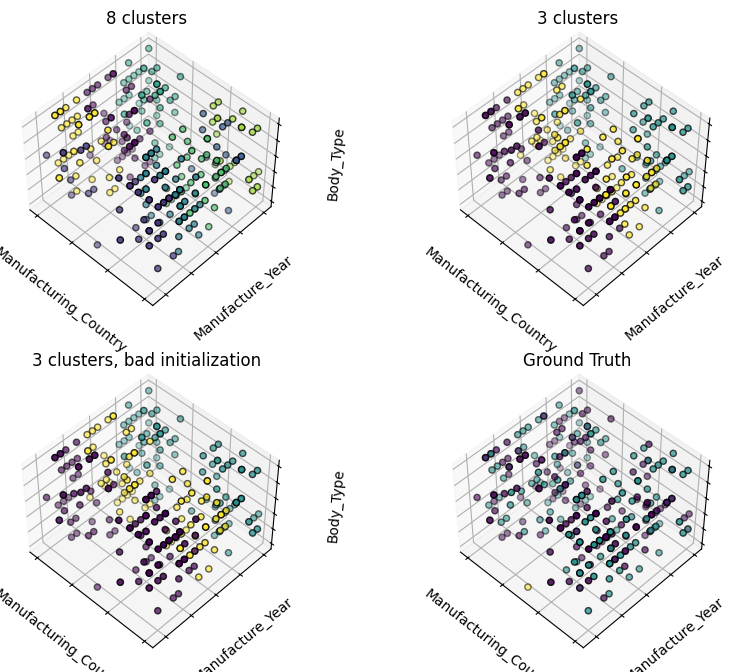

In [40]:
estimators = [
    ("k_means_iris_8", KMeans(n_clusters=8)),
    ("k_means_iris_3", KMeans(n_clusters=3)),
    ("k_means_iris_bad_init", KMeans(n_clusters=3, n_init=1, init="random")),
]

fig = plt.figure(figsize=(10, 8))
titles = ["8 clusters", "3 clusters", "3 clusters, bad initialization"]
for idx, ((name, est), title) in enumerate(zip(estimators, titles)):
    ax = fig.add_subplot(2, 2, idx + 1, projection="3d", elev=48, azim=134)
    est.fit(X)
    labels = est.labels_

    ax.scatter(X["Manufacturing_Country"], X["Manufacture_Year"], X["Body_Type"], c=labels.astype(float), edgecolor="k")

    ax.xaxis.set_ticklabels([])
    ax.yaxis.set_ticklabels([])
    ax.zaxis.set_ticklabels([])
    ax.set_xlabel("Manufacturing_Country")
    ax.set_ylabel("Manufacture_Year")
    ax.set_zlabel("Body_Type")

    ax.set_title(title)

# Plot the ground truth
ax = fig.add_subplot(2, 2, 4, projection="3d", elev=48, azim=134)

for name, label in [(vals[0], 0), (vals[1], 1), (vals[2], 2)]:
    ds = dataset[dataset["Transmission"]==name]
    ax.text3D(
        ds["Manufacturing_Country"].mean(),
        ds["Manufacture_Year"].mean(),
        ds["Body_Type"].mean(),
        name,
        horizontalalignment="center",
        bbox=dict(alpha=0.2, edgecolor="w", facecolor="w"),
    )

ax.scatter(X["Manufacturing_Country"], X["Manufacture_Year"], X["Body_Type"], c=y, edgecolor="k")

ax.xaxis.set_ticklabels([])
ax.yaxis.set_ticklabels([])
ax.zaxis.set_ticklabels([])
ax.set_xlabel("Manufacturing_Country")
ax.set_ylabel("Manufacture_Year")
ax.set_zlabel("Body_Type")
ax.set_title("Ground Truth")

plt.subplots_adjust(wspace=0.25, hspace=0.25)
plt.show()

Графики наглядно демонстрируютособенность алгоритма K-Means, его чувствительность к начальной инициализации и важность правильного выбора количества кластеров. Наилучший результат показывает модель с 3 кластерами

Метрики

Оценка производительности алгоритма кластеризации не так тривиальна, как подсчет количества ошибок или точности и полноты контролируемого алгоритма классификации. В частности, любая метрика оценки не должна принимать во внимание абсолютные значения меток кластера, а, скорее, если эта кластеризация определяет разделение данных, подобное некоторому базовому набору классов или удовлетворяющее некоторому предположению, например, что точки принадлежат к одному и тому же классу, они более похожи, чем представители разных классов по некоторой метрике сходства



In [41]:
from sklearn import metrics
from sklearn.metrics.cluster import adjusted_rand_score


n_clusters = np.arange(2, 21)

In [42]:
best_metric = [0, 10000, 0,[]]

silhouette_score_values = []
adjusted_rand_score_values = []

# Просто берем первый столбец или делаем ravel
y_1d = y.values.ravel() if hasattr(y, 'values') else y.ravel()

for n in n_clusters:
    clusterer = KMeans(n_clusters=n, max_iter=10, n_init=10)
    clusterer.fit(X)
    y_pred = clusterer.predict(X)

    score1 = metrics.silhouette_score(X, y_pred)
    silhouette_score_values.append(score1)

    score2 = metrics.adjusted_rand_score(y_1d, y_pred)
    adjusted_rand_score_values.append(score2)

    if score1 < best_metric[1] and score2 > best_metric[2]:
        best_metric[1] = score1
        best_metric[2] = score2
        best_metric[3] = clusterer.cluster_centers_
        best_metric[0] = n

In [43]:
best_metric

[np.int64(2),
 np.float64(0.49823645268121464),
 0.004316468201845882,
 array([[ 2.94155844,  5.09090909,  3.03896104],
        [ 2.91836735, 15.46938776,  3.19727891]])]

Алгоритм нашел 2 хорошо разделимых кластера

Индекс Рэнда (0.0043) близок к нулю, что означает разбиение на кластеры практически не совпадает с разметкой, результат кластеризации сильно отличается от "истинных" меток

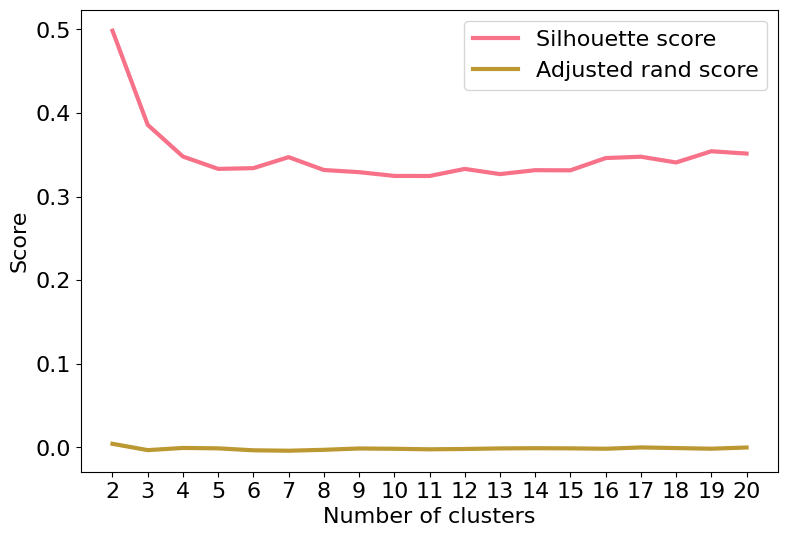

In [44]:
plt.figure(figsize=(9, 6))
plt.plot(n_clusters, silhouette_score_values, linewidth=3, label='Silhouette score')
plt.plot(n_clusters, adjusted_rand_score_values, linewidth=3, label='Adjusted rand score')
plt.xlabel('Number of clusters', size=16)
plt.ylabel('Score', size=16)
plt.xticks(n_clusters, size=16)
plt.yticks(size=16)
plt.legend(loc='best', fontsize=16)

plt.show()

Алгоритм K-Means способен находить структуру в данных, эта структура не совпадает с реальными классами объектов (индекс Рэнда почти 0).
Возникает проблема. Скорее всего выбранные признаки не позволяют разделить данные по заданным классам




In [45]:
from scipy.cluster.hierarchy import linkage, dendrogram

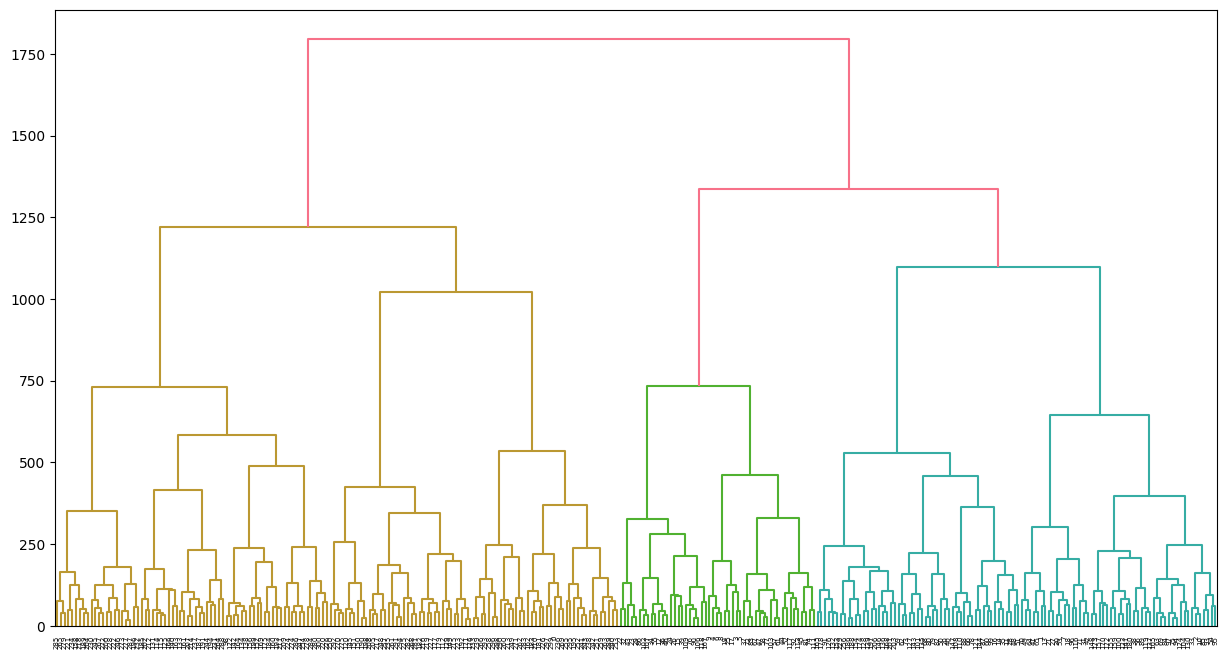

In [50]:
samples = df.values

# Реализация иерархической кластеризации при помощи функции linkage
mergings = linkage(samples, method='ward')
# попробуйте с другими методами
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.linkage.html

plt.figure(figsize=(15, 8))
# Строим дендрограмму, указав параметры удобные для отображения
dendrogram(mergings,
           leaf_rotation=90,
           leaf_font_size=5,
           )

plt.show()

Данные делятся на 4 кластера, где красная группа самая непохожая на другие

DBSCAN

Пространственная кластеризация приложений с шумом на основе плотности

Методы разбиения (K-средние, кластеризация PAM) и иерархическая кластеризация работают для поиска кластеров сферической формы или выпуклых кластеров. Другими словами, они подходят только для компактных и хорошо разделенных кластеров. Кроме того, на них также сильно влияет наличие шума и выбросов в данных.

In [51]:
from sklearn.cluster import DBSCAN
from sklearn import metrics
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn import datasets

In [52]:
mins = X.shape[1]

['y', 'b', 'g', 'r']


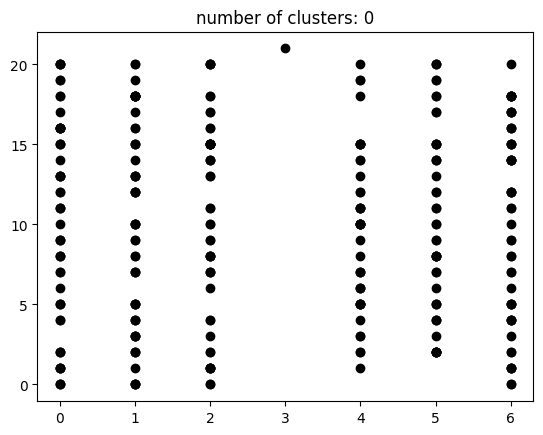

In [54]:
db = DBSCAN(eps=0.5, min_samples=12).fit(X)
core_samples_mask = np.zeros_like(db.labels_, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True
labels = db.labels_

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)

# Plot result

# Black removed and is used for noise instead.
unique_labels = set(labels)
colors = ['y', 'b', 'g', 'r']
print(colors)
for k, col in zip(unique_labels, colors):
	if k == -1:
		# Black used for noise.
		col = 'k'

	class_member_mask = (labels == k)

	xy = X[class_member_mask & core_samples_mask]
	plt.plot(xy["Manufacturing_Country"], xy["Manufacture_Year"], 'o', markerfacecolor=col,
			markeredgecolor='k',
			markersize=6)

	xy = X[class_member_mask & ~core_samples_mask]
	plt.plot(xy["Manufacturing_Country"], xy["Manufacture_Year"], 'o', markerfacecolor=col,
			markeredgecolor='k',
			markersize=6)

plt.title('number of clusters: %d' % n_clusters_)
plt.show()

График должен показывать точки на плоскости, но из-за неудачных параметров DBSCAN все точки считаются выбросами (черными)

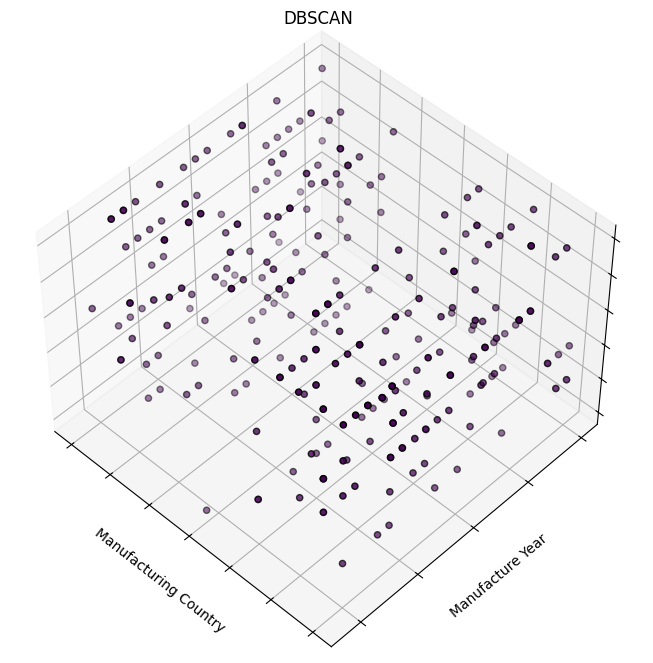

In [60]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(1, 1, 1, projection="3d", elev=48, azim=134)

ax.scatter(X["Manufacturing_Country"], X["Manufacture_Year"], X["Body_Type"],
           c=labels.astype(float), edgecolor="k")

ax.xaxis.set_ticklabels([])
ax.yaxis.set_ticklabels([])
ax.zaxis.set_ticklabels([])
ax.set_xlabel("Manufacturing Country")
ax.set_ylabel("Manufacture Year")
ax.set_zlabel("Body Type")
ax.set_title("DBSCAN")

plt.show()

 DBSCAN смог выделить несколько кластеров.Точки распределены достаточно плотно, алгоритм не нашел явных выбросов (нет черных точек).

Это похоже на осмысленную кластеризацию, где автомобили группируются по сочетанию страны производства и типа кузова в разные годы.